In [2]:
%matplotlib widget
from IPython.display import display, clear_output
import ipywidgets as widgets
from Sextet import MossbauerSextetModel
from lmfit.models import ConstantModel
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


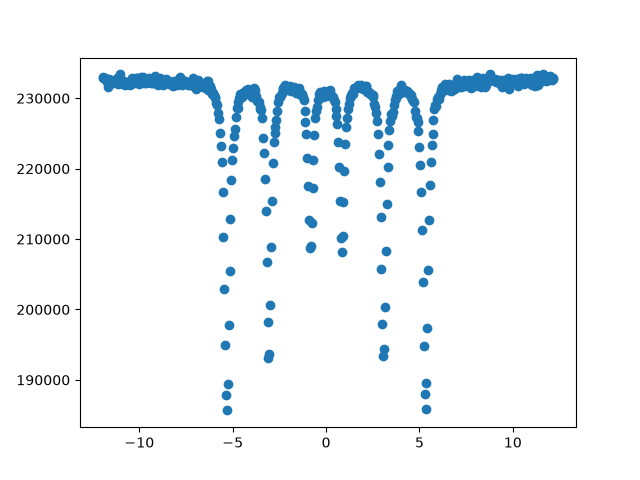

In [3]:
plt.close()
plt.figure()
data = pd.read_csv("Fe_kalibre_12mm-s.fld", sep=r'\s+')
v = data["V"]
Cnt = data["CNT"]

plt.scatter(v,Cnt)
plt.show()



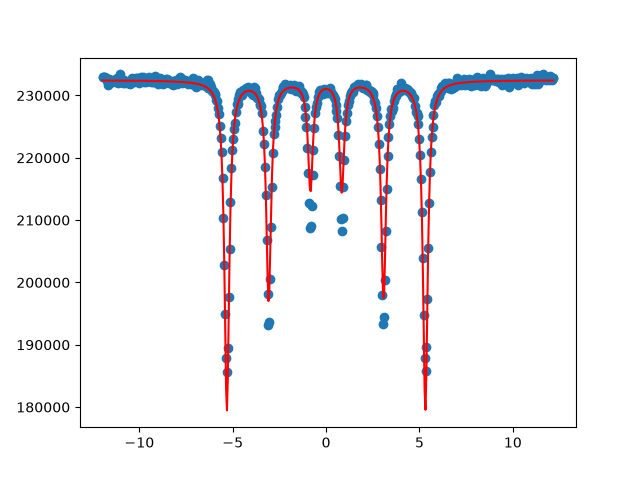

[[Model]]
    (Model(sextet_func) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 512
    # variables        = 5
    chi-square         = 7.6138e+08
    reduced chi-square = 1501739.76
    Akaike info crit   = 7286.70846
    Bayesian info crit = 7307.90008
    R-squared          = 0.97974144
[[Variables]]
    is_shift:   0.00157303 +/- 0.00126563 (80.46%) (init = 0.001573025)
    b_hf:       32.9531702 +/- 0.00911851 (0.03%) (init = 32.95317)
    eps:        0 (fixed)
    gamma:      0.30758181 +/- 0.00383430 (1.25%) (init = 0.3075818)
    amplitude: -102113.732 +/- 987.794422 (0.97%) (init = -102113.7)
    ratio:      2 (fixed)
    c:          232452.392 +/- 67.3838821 (0.03%) (init = 232452.4)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma, amplitude) = -0.7511
    C(amplitude, c)     = -0.5950
    C(gamma, c)         = +0.4437


In [25]:
plt.figure()
model = MossbauerSextetModel() + ConstantModel()
params = model.make_params()

# Background (the 'c' parameter from ConstantModel)
params['c'].set(value=np.max(Cnt), min=0)

# Hyperfine Field: 33.0 is the standard for alpha-Fe
params['b_hf'].set(value=33.2, min=0, max=50)

# Isomer Shift: Center of the spectrum
params['is_shift'].set(value=0.017, min=-2, max=2)

# Quadrupole shift (eps): usually very small for alpha-Fe
params['eps'].set(value=0.0, min=-1, max=1,vary=False)

# Linewidth (Gamma): standard is around 0.25 - 0.30
params['gamma'].set(value=0.3, min=0.1, max=1.0)

# Intensity Ratio (3:X:1): 2.0 is for random powder
params['ratio'].set(value=2.0, vary=False)

# Amplitude: This is the 'area' of the peaks.
# Since it's an absorption spectrum, it MUST be negative.
params['amplitude'].set(value=-100000, max=0)
result = model.fit(Cnt, params, x=v)
for i in range(20):
    params = result.params
    result = model.fit(Cnt, params, x=v)
plt.scatter(v,Cnt)
plt.plot(v,result.best_fit,color='red')
plt.show()

print(result.fit_report())

Read user input as in app test

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

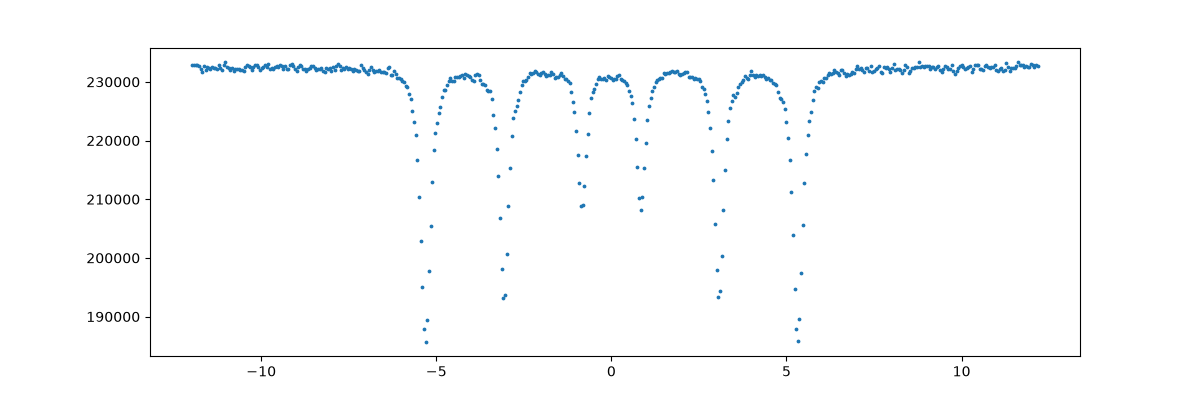

In [8]:
plt.close()
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(data['V'], data["CNT"],s=3)
#ax.legend()


# Widgets
var_field = widgets.IntText(
    value=1,
    description='Sextet',
    step=1,
    style={'description_width': 'initial'},
)
btn_bcg = widgets.Button(description='PickBacground', button_style='warning')
btn_run = widgets.Button(description='PickPeaks', button_style='success')
btn_reset = widgets.Button(description='Fit', button_style='warning')
out = widgets.Output(layout={'border': '1px solid lightgray'})

Bckg = np.nan
BckgPickInd = False
AddInd = False
hl = None
sl = None
pekas = None
NumOfPeaks = 1
Pickedv = []
y= []
results = None

def onclick(event):
    global sl,Pickedv, y, Bckg
    if BckgPickInd:
        global hl
        Bckg = event.ydata
        if(not hl is None):
            hl.remove()
        hl = ax.hlines(Bckg,data['V'].min(),data["V"].max(),ls = '--', color='r')
    if AddInd:
        if event.button == 1 and len(Pickedv) < 2:
            Pickedv.append(event.xdata)
            y.append(event.ydata)
        else:
            Pickedv.pop(-1)
            y.pop(-1)
        if not sl is None:
            sl.remove()
            sl = None
        sl = ax.scatter(Pickedv,y,color = 'r')


def on_add(event):
    global AddInd
    AddInd = not AddInd

@out.capture(clear_output=True)
def on_Fit(event):
    global Pickedv, y, results, Bckg

    print("Fit button clicked! Processing...")

    if len(Pickedv) < 2:
        print(f"Error: You have only picked {len(Pickedv)} peaks. You need exactly 2 to estimate b_hf!")
        return

    try:
        v1 = np.sort(np.array(Pickedv))
        is_guess = v1.mean()
        gg = 0.181208
        ge = -0.103542
        C = 0.65569

        bf1 = v1[0] / (is_guess + (1.5 * ge - 0.5 * gg) * C)
        bf2 = v1[1] / (is_guess + (-1.5 * ge + 0.5 * gg) * C)
        bf_guess = (bf1 + bf2) / 2
        model = MossbauerSextetModel() + ConstantModel()
        params = model.make_params()

        params['c'].set(value=Bckg if not np.isnan(Bckg) else data["CNT"].max(), min=0)
        params['b_hf'].set(value=bf_guess, min=0, max=50)
        params['is_shift'].set(value=is_guess, min=-2, max=2)
        params['eps'].set(value=0.0, min=-1, max=1, vary=False)
        params['gamma'].set(value=0.3, min=0.1, max=1.0)
        params['ratio'].set(value=2.0, vary=False)
        params['amplitude'].set(value= np.mean(y) - Bckg if len(y) > 0 else -100000, max=0)

        # Run optimization
        results = model.fit(data["CNT"], params, x=data["V"])

        # --- FIXED LINE HERE ---
        ax.plot(data["V"], results.best_fit, color='red', linewidth=2, label='Mössbauer Fit')
        ax.legend()
        fig.canvas.draw_idle()

        # Print confirmation and summary directly inside 'out'
        print("Success! Fit has been plotted on the graph.")
        print(results.fit_report())

    except Exception as e:
        print(f"An error occurred during fitting calculation: {str(e)}")
def BckPick(event):
    global BckgPickInd
    BckgPickInd = not BckgPickInd
    pass
# Connect the click event
btn_run.on_click(on_add)
btn_reset.on_click(on_Fit)
btn_bcg.on_click(BckPick)
# Layout and display
controls = widgets.HBox([var_field,btn_bcg, btn_run, btn_reset])
display(controls, out)
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()